# Instructor Effectiveness Modeling (EdTech)

This notebook uses the real CSV at `data/instructor_data.csv` to build a course-adjusted effectiveness proxy for coaching and support. It does not create synthetic data and does not make personnel decisions.


## 1. Setup and Load

We set one random seed, use relative paths, select the requested CSV deterministically, and inspect its structure before analysis. No synthetic or fallback data is allowed.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_fscore_support
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
DATA_DIR = Path("data")
requested_path = DATA_DIR / "instructor_data.csv"
csv_paths = sorted(DATA_DIR.glob("*.csv"))
DATA_PATH = requested_path if requested_path.exists() else (csv_paths[0] if len(csv_paths) == 1 else None)
if DATA_PATH is None:
    # Colab users can upload the real CSV; no fallback data is ever created.
    try:
        from google.colab import files
        uploaded = files.upload()
        uploaded_csvs = [Path(name) for name in uploaded if name.lower().endswith(".csv")]
        if len(uploaded_csvs) == 1:
            DATA_PATH = uploaded_csvs[0]
    except Exception as upload_error:
        print("Colab upload unavailable:", type(upload_error).__name__)
if DATA_PATH is None:
    raise FileNotFoundError("No real CSV found. Put instructor_data.csv in data/ or upload one CSV in Colab.")

df = pd.read_csv(DATA_PATH)
required = ["batch_id", "instructor_id", "course_id", "completion_rate", "dropout_rate", "avg_score_improvement", "avg_quiz_score", "avg_watch_time", "assignment_submission_rate", "forum_activity_rate", "avg_feedback_score", "feedback_response_rate"]
column_map = {}
missing_required = sorted(set(required) - set(df.columns))
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}. Add an explicit column_map before loading.")
print(f"DATA_PATH: {DATA_PATH}")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Dtypes:\n", df.dtypes)
print("Head:\n", df.head())
print("Missing counts:\n", df.isna().sum())
assert set(required).issubset(df.columns)


DATA_PATH: data\instructor_data.csv
Shape: (2000, 12)
Columns: ['batch_id', 'instructor_id', 'course_id', 'completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate']
Dtypes:
 batch_id                          str
instructor_id                     str
course_id                         str
completion_rate               float64
avg_score_improvement         float64
avg_quiz_score                float64
dropout_rate                  float64
avg_watch_time                float64
assignment_submission_rate    float64
forum_activity_rate           float64
avg_feedback_score            float64
feedback_response_rate        float64
dtype: object
Head:
   batch_id instructor_id course_id  completion_rate  avg_score_improvement  \
0   B_1861         I_044      C_01         0.300000              14.225955   
1   B_0354         I_119      C_06         0.657220    

## 2. EDA: Data Quality and Distributions

These checks use only the real CSV. The plots are interpreted in the following Early Observations markdown cell, including clipping, outcome-engagement associations, redundancy, feedback response bias, and instructor-level clustering.


Duplicate rows: 0
Out-of-range rate counts: {'completion_rate': 0, 'dropout_rate': 0, 'avg_watch_time': 0, 'assignment_submission_rate': 0, 'forum_activity_rate': 0, 'feedback_response_rate': 0}
Out-of-range feedback count: 0
Completion + dropout summary:
 count    2000.000000
mean        0.997692
std         0.049259
min         0.828710
25%         0.965302
50%         0.999425
75%         1.029358
max         1.160438
dtype: float64
Rows outside +/- 0.05 consistency tolerance: 625
Completion == 0.30: 77
Dropout == 0.70: 72
Exact feedback 5.0: 67
Exact watch time 1.0: 149
Completion/dropout correlation: -0.9535
Outcome-vs-engagement correlations:
                        avg_watch_time  assignment_submission_rate  \
completion_rate                0.1876                      0.2219   
dropout_rate                  -0.1705                     -0.2105   
avg_score_improvement          0.1284                      0.1289   
avg_quiz_score                 0.1106                      0.1157 

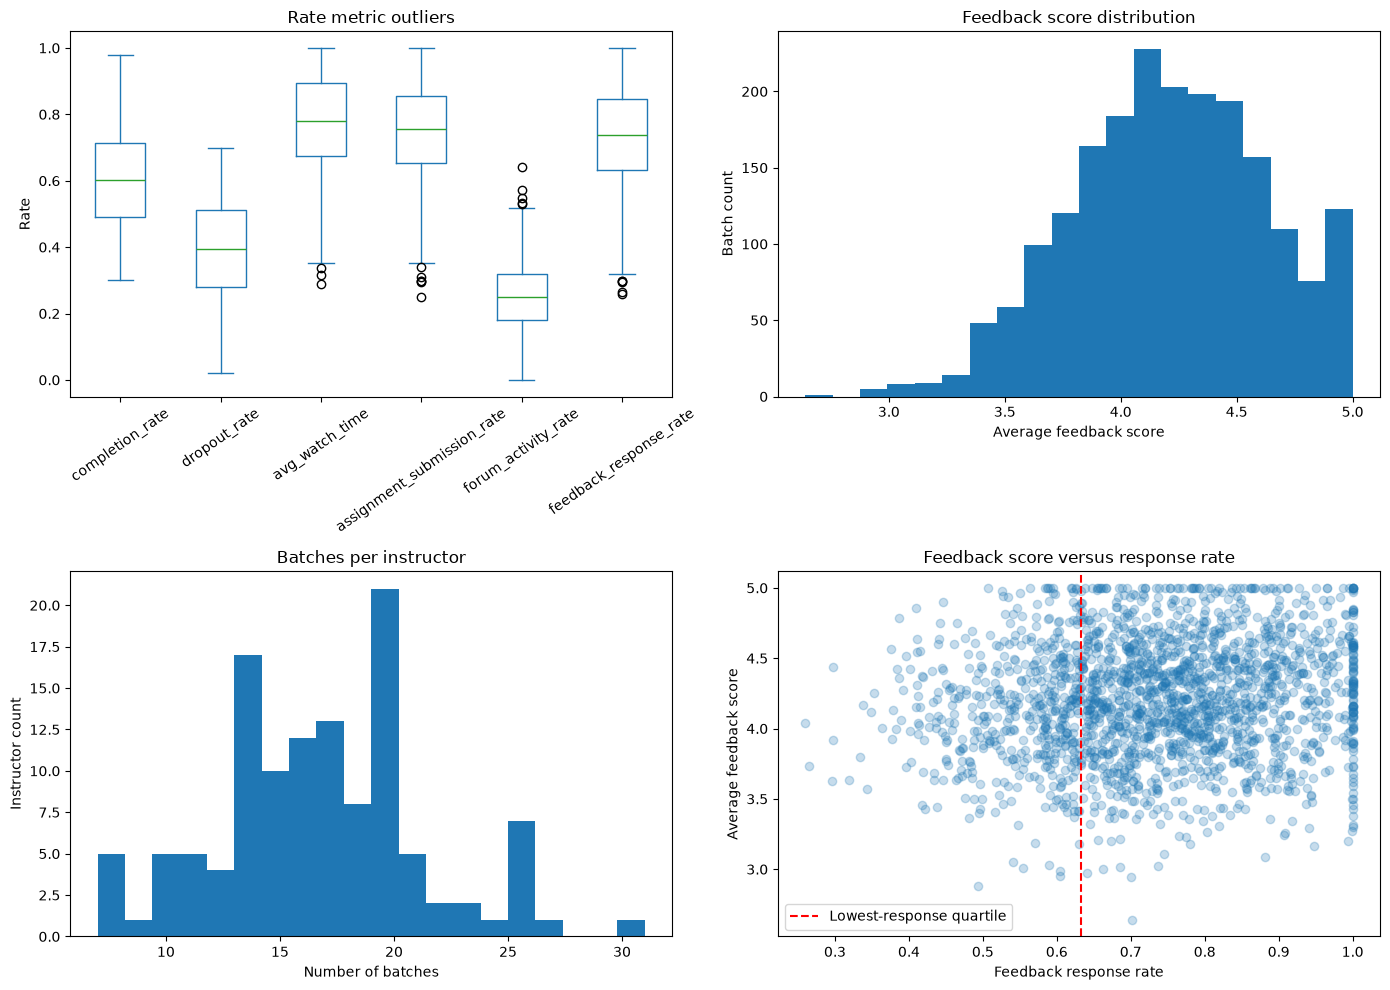

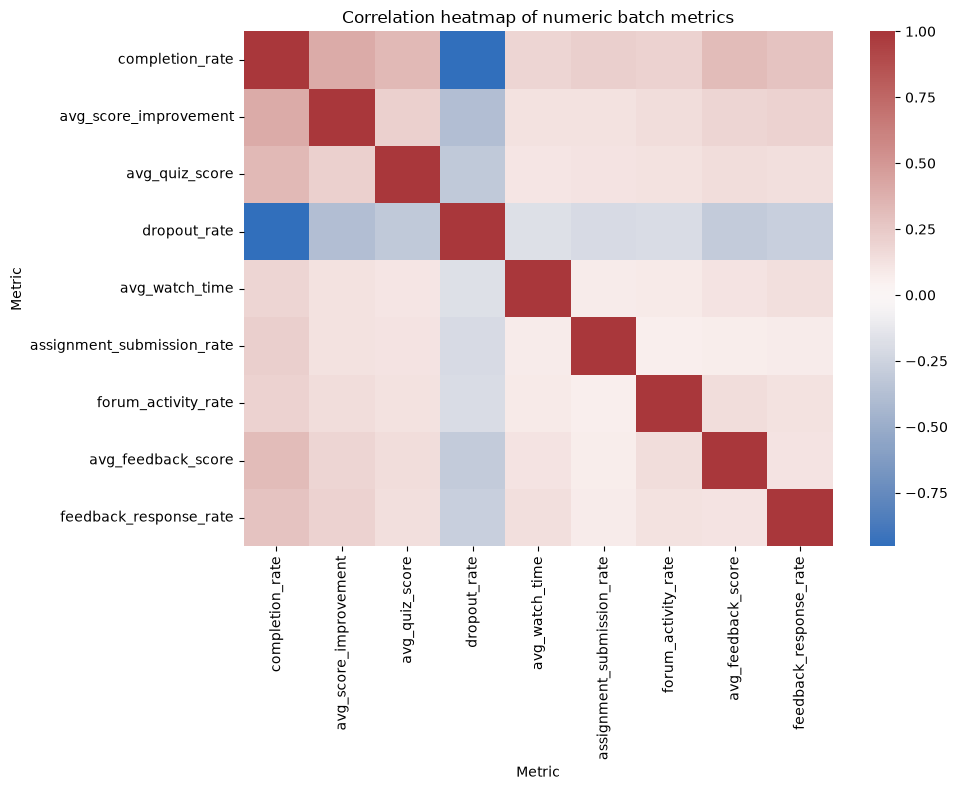

In [2]:
rate_cols = ["completion_rate", "dropout_rate", "avg_watch_time", "assignment_submission_rate", "forum_activity_rate", "feedback_response_rate"]
outcome_cols = ["completion_rate", "dropout_rate", "avg_score_improvement", "avg_quiz_score", "avg_feedback_score"]
print("Duplicate rows:", int(df.duplicated().sum()))
range_checks = {column: int(((df[column] < 0) | (df[column] > 1)).sum()) for column in rate_cols}
feedback_check = int(((df["avg_feedback_score"] < 1) | (df["avg_feedback_score"] > 5)).sum())
consistency = df["completion_rate"] + df["dropout_rate"]
print("Out-of-range rate counts:", range_checks)
print("Out-of-range feedback count:", feedback_check)
print("Completion + dropout summary:\n", consistency.describe())
print("Rows outside +/- 0.05 consistency tolerance:", int((consistency.sub(1).abs() > 0.05).sum()))
print("Completion == 0.30:", int((df["completion_rate"] == 0.30).sum()))
print("Dropout == 0.70:", int((df["dropout_rate"] == 0.70).sum()))
print("Exact feedback 5.0:", int((df["avg_feedback_score"] == 5.0).sum()))
print("Exact watch time 1.0:", int((df["avg_watch_time"] == 1.0).sum()))
print("Completion/dropout correlation:", round(float(df[["completion_rate", "dropout_rate"]].corr().iloc[0, 1]), 4))
print("Outcome-vs-engagement correlations:\n", df[outcome_cols + ["avg_watch_time", "assignment_submission_rate", "forum_activity_rate"]].corr().loc[outcome_cols, ["avg_watch_time", "assignment_submission_rate", "forum_activity_rate"]].round(4))
instructor_means = df.groupby("instructor_id")["avg_score_improvement"].mean()
within_var = df.groupby("instructor_id")["avg_score_improvement"].var().mean()
between_var = instructor_means.var()
intraclass_correlation = between_var / (between_var + within_var)
print("Intraclass correlation for avg_score_improvement:", round(float(intraclass_correlation), 4))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df[rate_cols].plot(kind="box", ax=axes[0, 0], rot=35, title="Rate metric outliers")
axes[0, 0].set_ylabel("Rate")
df["avg_feedback_score"].plot(kind="hist", bins=20, ax=axes[0, 1], title="Feedback score distribution", legend=False)
axes[0, 1].set_xlabel("Average feedback score")
axes[0, 1].set_ylabel("Batch count")
df.groupby("instructor_id")["batch_id"].nunique().plot(kind="hist", bins=20, ax=axes[1, 0], title="Batches per instructor")
axes[1, 0].set_xlabel("Number of batches")
axes[1, 0].set_ylabel("Instructor count")
low_response = df["feedback_response_rate"] <= df["feedback_response_rate"].quantile(0.25)
axes[1, 1].scatter(df["feedback_response_rate"], df["avg_feedback_score"], alpha=0.25)
axes[1, 1].axvline(df.loc[low_response, "feedback_response_rate"].max(), color="red", linestyle="--", label="Lowest-response quartile")
axes[1, 1].set(title="Feedback score versus response rate", xlabel="Feedback response rate", ylabel="Average feedback score")
axes[1, 1].legend()
plt.tight_layout()

plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="vlag", center=0)
plt.title("Correlation heatmap of numeric batch metrics")
plt.xlabel("Metric")
plt.ylabel("Metric")
plt.tight_layout()


### Early Observations and Plot Reading

The real data contain `625` completion/dropout mismatches beyond tolerance, with completion clipped at `0.30` in `77` rows and dropout capped at `0.70` in `72` rows. The completion/dropout correlation is `-0.9535`, so these measures are largely redundant.

The box plot shows metric spread and clipping; the feedback histogram shows ceiling concentration; the batches-per-instructor histogram shows experience coverage; the feedback scatter tests response-rate bias; and the heatmap summarizes correlations. The outcome-vs-engagement table and ICC `0.3095` provide association evidence, not causal proof.


### Early Observations and Plot Interpretation

The real data contain `625` completion/dropout mismatches beyond tolerance, with completion clipped at `0.30` in `77` rows and dropout capped at `0.70` in `72` rows. The box plot shows metric spread and clipping; the feedback histogram shows ceiling concentration; the batch histogram shows experience coverage; the scatter tests response-rate bias; and the heatmap summarizes correlations. The outcome-vs-engagement table and ICC provide association evidence, not causal proof.


## 3. Course-Adjusted Effectiveness Score

Each outcome and feedback metric is standardized within course. The score weights learning outcomes at 0.60, feedback at 0.25, and consistency at 0.15. Shrinkage uses a noise-corrected between-instructor variance so the prior reflects sampling noise rather than treating all raw mean separation as real.


In [3]:
metric_cols = ["completion_rate", "dropout_rate", "avg_score_improvement", "avg_quiz_score", "avg_feedback_score"]
df["positive_dropout"] = 1 - df["dropout_rate"]
score_parts = ["completion_rate", "positive_dropout", "avg_score_improvement", "avg_quiz_score"]
for column in metric_cols + ["positive_dropout"]:
    # Course normalization compares instructors within the same course.
    course_mean = df.groupby("course_id")[column].transform("mean")
    course_std = df.groupby("course_id")[column].transform("std").replace(0, np.nan)
    raw_z = (df[column] - course_mean) / course_std
    # Singleton or constant courses have no estimable spread, so their neutral z-score is explicit.
    df[f"z_{column}"] = raw_z.where(course_std.notna(), 0.0)

df["learning_outcomes"] = df[[f"z_{column}" for column in score_parts]].mean(axis=1)
# Low response downweights unusually positive feedback, while negative feedback is conservatively penalized.
response_floor = max(float(df["feedback_response_rate"].quantile(0.25)), 0.25)
feedback_z = df["z_avg_feedback_score"]
reliability = df["feedback_response_rate"].clip(lower=response_floor)
df["feedback_component"] = np.where(feedback_z >= 0, feedback_z * reliability, feedback_z / reliability)
negative_feedback = feedback_z < -1
feedback_response_corr = df.loc[negative_feedback, ["feedback_response_rate", "feedback_component"]].corr().iloc[0, 1]
symmetric_feedback_mean = float((feedback_z * reliability).mean())
print("Feedback response floor:", round(response_floor, 4))
print("Correlation(response_rate, feedback_component) for z_feedback < -1:", round(float(feedback_response_corr), 4))
print("Asymmetric feedback component mean:", round(float(df["feedback_component"].mean()), 4))
print("Symmetric z-times-reliability mean for comparison:", round(symmetric_feedback_mean, 4))
# Explicitly use a neutral consistency value only if an instructor has one batch and no estimable spread.
consistency_std = df.groupby("instructor_id")["learning_outcomes"].transform("std")
df["consistency_component"] = (1 - consistency_std.clip(upper=1)).where(consistency_std.notna(), 1.0)
df["effectiveness_score"] = 0.60 * df["learning_outcomes"] + 0.25 * df["feedback_component"] + 0.15 * df["consistency_component"]

instructor_scores = df.groupby("instructor_id")["effectiveness_score"].agg(raw_mean="mean", within_variance="var")
global_mean = df["effectiveness_score"].mean()
within_variance = instructor_scores["within_variance"].mean()
instructor_scores["n_batches"] = df.groupby("instructor_id")["batch_id"].nunique()
between_variance = instructor_scores["raw_mean"].var()
noise_corrected_tau2 = max(float(between_variance - within_variance / instructor_scores["n_batches"].mean()), 1e-6)
prior_strength = max(float(within_variance / noise_corrected_tau2), 0.1)
instructor_scores["shrink_weight"] = instructor_scores["n_batches"] / (instructor_scores["n_batches"] + prior_strength)
instructor_scores["shrunk_score"] = instructor_scores["shrink_weight"] * instructor_scores["raw_mean"] + (1 - instructor_scores["shrink_weight"]) * global_mean
raw_cuts = instructor_scores["raw_mean"].quantile([1/3, 2/3]).to_numpy()
shrunk_cuts = instructor_scores["shrunk_score"].quantile([1/3, 2/3]).to_numpy()
instructor_scores["raw_tier"] = pd.cut(instructor_scores["raw_mean"], bins=[-np.inf, *raw_cuts, np.inf], labels=["Low", "Medium", "High"], include_lowest=True)
instructor_scores["tier"] = pd.cut(instructor_scores["shrunk_score"], bins=[-np.inf, *shrunk_cuts, np.inf], labels=["Low", "Medium", "High"], include_lowest=True)
instructor_scores["low_confidence"] = instructor_scores["shrink_weight"] < 0.95
tier_changes = int((instructor_scores["raw_tier"].astype(str) != instructor_scores["tier"].astype(str)).sum())
final_instructor_means = df.groupby("instructor_id")["effectiveness_score"].mean()
final_within_variance = df.groupby("instructor_id")["effectiveness_score"].var().mean()
final_between_variance = final_instructor_means.var()
final_score_icc = final_between_variance / (final_between_variance + final_within_variance)
print("Global mean, within variance, between variance:", round(global_mean, 4), round(within_variance, 4), round(between_variance, 4))
print("Noise-corrected tau-squared:", round(noise_corrected_tau2, 4))
print("Prior strength:", round(prior_strength, 4))
print("Minimum batches per instructor:", int(instructor_scores["n_batches"].min()))
print("Final score ICC:", round(float(final_score_icc), 4), "(consistency_component is constant per instructor and inflates this descriptive ICC)")
print("Tier counts after shrinkage:\n", instructor_scores["tier"].value_counts().sort_index())
print("Raw-to-shrunk tier changes:", tier_changes)
print("Low-confidence instructors:", int(instructor_scores["low_confidence"].sum()))


Feedback response floor: 0.6333
Correlation(response_rate, feedback_component) for z_feedback < -1: 0.4097
Asymmetric feedback component mean: -0.2403
Symmetric z-times-reliability mean for comparison: 0.0123
Global mean, within variance, between variance: 0.0242 0.1399 0.2409
Noise-corrected tau-squared: 0.2325
Prior strength: 0.6018
Minimum batches per instructor: 7
Final score ICC: 0.6326 (consistency_component is constant per instructor and inflates this descriptive ICC)
Tier counts after shrinkage:
 tier
Low       40
Medium    40
High      40
Name: count, dtype: int64
Raw-to-shrunk tier changes: 0
Low-confidence instructors: 16


### Feedback Component Design

The asymmetric rule is intentional: positive feedback is multiplied by response reliability, so low response cannot create an inflated positive signal; negative feedback is divided by the reliability floor, so low response cannot rescue poor feedback. The code prints both the asymmetric component mean and a symmetric comparison mean, allowing the score effect to be inspected from the real data.


## 4. Instructor-Level Aggregation and Confidence

Means describe typical performance; medians resist outliers; plain standard deviation describes spread; min/max and their gap show floor-to-ceiling variation. Batch IDs are not a verified timeline, so trend slope is descriptive only and recent weighting is not used. The real data have a minimum of 7 batches per instructor, so the few-batch concern does not occur here; the shrinkage and stability simulations demonstrate how uncertainty should be handled in smaller samples.


In [4]:
def trend_slope(values):
    values = np.asarray(values, dtype=float)
    return float(np.polyfit(np.arange(len(values)), values, 1)[0]) if len(values) >= 2 else 0.0

grouped = df.sort_values(["instructor_id", "batch_id"]).groupby("instructor_id")
agg = grouped["effectiveness_score"].agg(mean="mean", median="median", std="std", min="min", max="max")
agg["best_worst_gap"] = agg["max"] - agg["min"]
agg["trend_slope_batch_order"] = grouped["effectiveness_score"].apply(trend_slope)
agg["n_batches"] = grouped["batch_id"].nunique()
agg["n_courses"] = grouped["course_id"].nunique()
agg["raw_mean"] = instructor_scores["raw_mean"]
agg["shrunk_score"] = instructor_scores["shrunk_score"]
agg["shrink_weight"] = instructor_scores["shrink_weight"]
agg["low_confidence"] = instructor_scores["low_confidence"]
agg["tier"] = instructor_scores["tier"]
agg["raw_tier"] = instructor_scores["raw_tier"]
print(agg.describe(include="all"))
print("Minimum batches per instructor:", int(agg["n_batches"].min()))
print("Low-confidence batch-count range:", int(agg.loc[agg["low_confidence"], "n_batches"].min()), "to", int(agg.loc[agg["low_confidence"], "n_batches"].max()))
print("Trend slope is descriptive only because batch_id is not a verified timeline.")


              mean      median         std         min         max  \
count   120.000000  120.000000  120.000000  120.000000  120.000000   
unique         NaN         NaN         NaN         NaN         NaN   
top            NaN         NaN         NaN         NaN         NaN   
freq           NaN         NaN         NaN         NaN         NaN   
mean      0.023602    0.040975    0.367499   -0.676817    0.641172   
std       0.490833    0.485655    0.070184    0.575971    0.485790   
min      -1.210694   -1.203185    0.168074   -2.192962   -0.476681   
25%      -0.287157   -0.282242    0.324438   -1.005249    0.367576   
50%       0.006516    0.040606    0.369475   -0.714431    0.605769   
75%       0.270438    0.312155    0.414926   -0.387142    1.008000   
max       1.235381    1.203048    0.493348    0.700626    1.685167   

        best_worst_gap  trend_slope_batch_order   n_batches   n_courses  \
count       120.000000               120.000000  120.000000  120.000000   
unique   

### Aggregation Interpretation

The table reports plain mean, median, standard deviation, min, max, best-to-worst gap, a descriptive batch-order slope, and experience/versatility counts. Shrinkage uses the printed noise-corrected tau-squared and the real minimum of 7 batches; no recent weighting is used because batch_id is not a verified timeline.

The low-confidence threshold is `shrink_weight < 0.95`, a judgment call that flags the printed count of instructors; in this dataset it corresponds to the lowest-batch instructors, approximately 7–12 batches based on the printed aggregation summary.


## 5. Leakage-Safe Modeling Features and Models

Production features use engagement summaries, engagement consistency, experience, and versatility only. Plain standard deviations replace CV because CV is not meaningful for z-scored values centred near zero. Outcome-derived aggregates and score statistics remain outside production features and appear only in a diagnostic ablation. We compare baseline and classical models with repeated grouped validation.


In [5]:
model_df = agg.copy()
engagement_features = ["avg_watch_time", "assignment_submission_rate", "forum_activity_rate"]
engagement_agg = df.groupby("instructor_id")[engagement_features].agg(["mean", lambda values: values.std(ddof=0)])
engagement_agg.columns = [f"{column}_{'mean' if statistic == 'mean' else 'std'}" for column, statistic in engagement_agg.columns]
model_df = model_df.join(engagement_agg, how="left")
raw_engagement_features = [f"{column}_{statistic}" for column in engagement_features for statistic in ["mean", "std"]]
assert model_df[raw_engagement_features].isna().sum().sum() == 0, "Engagement feature join created NaNs"
model_df["engagement_consistency"] = 1 / (1 + model_df[[f"{column}_std" for column in engagement_features]].mean(axis=1))
engagement_only_features = raw_engagement_features
production_features = raw_engagement_features + ["engagement_consistency", "n_batches", "n_courses"]

def prune_correlated(features, threshold=0.90):
    # Remove redundant engagement predictors while keeping the feature policy explicit.
    corr = model_df[features].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    return [column for column in upper.columns if not (upper[column] > threshold).any()]

selected_features = prune_correlated(production_features)
selected_engagement_features = prune_correlated(engagement_only_features)
X = model_df[selected_features].astype(float)
X_engagement = model_df[selected_engagement_features].astype(float)
assert X.notna().all().all() and X_engagement.notna().all().all()
y = model_df["tier"].astype(str)
groups = model_df.index.to_numpy()
models = {
    "Dummy majority baseline": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Stratified-random chance baseline": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "Engagement-only Logistic": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))]),
    "Logistic Regression": Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))]),
    # Single-threaded forests avoid joblib configuration warnings inside repeated grouped CV.
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}
full_feature_models = {name: estimator for name, estimator in models.items() if name not in ["Engagement-only Logistic"]}
repeats = 10
folds = 5

def repeated_grouped_evaluation(name, estimator, features):
    fold_rows = []
    predictions_by_repeat = []
    for repeat in range(repeats):
        # Each repeat changes only the grouped split seed; all instructors remain isolated between train and test.
        splitter = StratifiedGroupKFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE + repeat)
        repeat_predictions = np.empty(len(y), dtype=object)
        for train_idx, test_idx in splitter.split(features, y, groups):
            fitted = clone(estimator).fit(features.iloc[train_idx], y.iloc[train_idx])
            predictions = fitted.predict(features.iloc[test_idx])
            repeat_predictions[test_idx] = predictions
            fold_rows.append({"model": name, "repeat": repeat + 1, "macro_f1": f1_score(y.iloc[test_idx], predictions, average="macro"), "ordinal_error": np.mean(np.abs(y.iloc[test_idx].map({"Low": 0, "Medium": 1, "High": 2}).to_numpy() - pd.Series(predictions).map({"Low": 0, "Medium": 1, "High": 2}).to_numpy()))})
        predictions_by_repeat.append(repeat_predictions)
    return pd.DataFrame(fold_rows), predictions_by_repeat

feature_sets = {name: X for name in full_feature_models}
feature_sets["Engagement-only Logistic"] = X_engagement
all_fold_rows = []
all_predictions = {}
for name, estimator in models.items():
    fold_rows, repeat_predictions = repeated_grouped_evaluation(name, estimator, feature_sets[name])
    all_fold_rows.append(fold_rows)
    all_predictions[name] = repeat_predictions
fold_results = pd.concat(all_fold_rows, ignore_index=True)
results_df = fold_results.groupby("model").agg(macro_f1_mean=("macro_f1", "mean"), macro_f1_std=("macro_f1", "std"), ordinal_error_mean=("ordinal_error", "mean"), ordinal_error_std=("ordinal_error", "std")).sort_values("macro_f1_mean", ascending=False)
print("Selected production features:", selected_features)
print("Repeated grouped results (10 repeats x 5 folds):\n", results_df)


Selected production features: ['avg_watch_time_mean', 'avg_watch_time_std', 'assignment_submission_rate_mean', 'assignment_submission_rate_std', 'forum_activity_rate_mean', 'forum_activity_rate_std', 'engagement_consistency', 'n_batches', 'n_courses']
Repeated grouped results (10 repeats x 5 folds):
                                    macro_f1_mean  macro_f1_std  \
model                                                            
Engagement-only Logistic                0.628616      0.099525   
Logistic Regression                     0.619151      0.100353   
Random Forest                           0.583745      0.088243   
Gradient Boosting                       0.581066      0.087339   
Stratified-random chance baseline       0.371926      0.085308   
Dummy majority baseline                 0.166667      0.000000   

                                   ordinal_error_mean  ordinal_error_std  
model                                                                     
Engagement-only Log

## 6. Models and Correlation-Based Feature Pruning

Production features use engagement summaries, engagement consistency, experience, and versatility only. The join assertion runs before any imputation. Classical models and baselines are compared with repeated grouped validation; outcome-derived features remain in a separate diagnostic ablation.


In [6]:
# The ablation deliberately includes outcome-derived summaries to demonstrate circularity.
leaky_features = list(dict.fromkeys(selected_features + ["mean", "median", "std", "trend_slope_batch_order", "raw_mean", "shrunk_score"]))
leaky_X = model_df[leaky_features].astype(float)
assert leaky_X.notna().all().all(), "Leaky ablation unexpectedly contains NaNs"
leaky_fold_rows, leaky_predictions = repeated_grouped_evaluation("Outcome-derived leaky ablation", models["Logistic Regression"], leaky_X)
leaky_mean = float(leaky_fold_rows["macro_f1"].mean())
leaky_std = float(leaky_fold_rows["macro_f1"].std())
print("Outcome-derived leaky ablation macro-F1 mean +/- std:", round(leaky_mean, 4), "+/-", round(leaky_std, 4))
print("This is diagnostic only: outcome-derived features are circular and excluded from production.")


Outcome-derived leaky ablation macro-F1 mean +/- std: 0.8709 +/- 0.0604
This is diagnostic only: outcome-derived features are circular and excluded from production.


### Model Comparison Interpretation

The production feature set is engagement-only plus experience and versatility. The join assertion runs before any imputation, and production features contain no outcome score summaries; the leaky ablation is diagnostic only.


## 7. Grouped Evaluation

Macro-F1 is primary because it gives each tier equal importance. All folds are grouped by instructor, so an instructor cannot appear in both train and test. We report repeated-CV mean +/- std, per-class precision/recall, confusion matrix, baseline lift, and ordinal error. The top model means are within one standard deviation, so this is comparative evidence rather than a definitive winner.


In [7]:
candidate_names = ["Engagement-only Logistic", "Logistic Regression", "Random Forest", "Gradient Boosting"]
highest_mean_model = results_df.loc[candidate_names, "macro_f1_mean"].idxmax()
highest_mean_f1 = float(results_df.loc[highest_mean_model, "macro_f1_mean"])
highest_mean_std = float(results_df.loc[highest_mean_model, "macro_f1_std"])
chance_f1_mean = float(results_df.loc["Stratified-random chance baseline", "macro_f1_mean"])
majority_f1_mean = float(results_df.loc["Dummy majority baseline", "macro_f1_mean"])
pooled_actual = np.tile(y.to_numpy(), repeats)
pooled_predictions = np.concatenate(all_predictions[highest_mean_model])
within_one_std = results_df.loc[candidate_names, "macro_f1_mean"] >= highest_mean_f1 - highest_mean_std
print("Highest observed mean model:", highest_mean_model)
print("Highest observed macro-F1 mean +/- std:", round(highest_mean_f1, 4), "+/-", round(highest_mean_std, 4))
print("Models within one highest-model std:", list(results_df.loc[candidate_names].index[within_one_std]))
classification_report_text = classification_report(pooled_actual, pooled_predictions, labels=["Low", "Medium", "High"], zero_division=0)
print("Classification report pooled over repeated test predictions:\n", classification_report_text)
confusion = pd.DataFrame(confusion_matrix(pooled_actual, pooled_predictions, labels=["Low", "Medium", "High"]), index=["Low", "Medium", "High"], columns=["Low", "Medium", "High"])
print("Confusion matrix pooled over repeated test predictions (rows true, columns predicted):\n", confusion)
ordinal = {"Low": 0, "Medium": 1, "High": 2}
ordinal_error = np.mean(np.abs(pd.Series(pooled_actual).map(ordinal).to_numpy() - pd.Series(pooled_predictions).map(ordinal).to_numpy()))
low_high_errors = int(confusion.loc["Low", "High"] + confusion.loc["High", "Low"])
print("Mean ordinal error:", round(float(ordinal_error), 4))
print("Low-to-High or High-to-Low errors:", low_high_errors)
print("Lift versus stratified chance baseline:", round(highest_mean_f1 - chance_f1_mean, 4))
print("Lift versus majority baseline:", round(highest_mean_f1 - majority_f1_mean, 4))


Highest observed mean model: Engagement-only Logistic
Highest observed macro-F1 mean +/- std: 0.6286 +/- 0.0995
Models within one highest-model std: ['Engagement-only Logistic', 'Logistic Regression', 'Random Forest', 'Gradient Boosting']
Classification report pooled over repeated test predictions:
               precision    recall  f1-score   support

         Low       0.70      0.67      0.69       400
      Medium       0.46      0.48      0.47       400
        High       0.74      0.74      0.74       400

    accuracy                           0.63      1200
   macro avg       0.63      0.63      0.63      1200
weighted avg       0.63      0.63      0.63      1200

Confusion matrix pooled over repeated test predictions (rows true, columns predicted):
         Low  Medium  High
Low     269     127     4
Medium  107     192   101
High      8      94   298
Mean ordinal error: 0.3775
Low-to-High or High-to-Low errors: 12
Lift versus stratified chance baseline: 0.2567
Lift versus ma

### Trade-offs and Class Imbalance

Tiers are balanced by construction: 40 Low, 40 Medium, and 40 High. Medium is hardest in the pooled report, with precision `0.46` and recall `0.48`, compared with Low precision/recall `0.70/0.67` and High `0.74/0.74`. Low-to-High and High-to-Low errors total `12`. For coaching, flagging Low favors recall, but precision also matters because wrongly labeling someone Low has a fairness cost. All four production model means are within one standard deviation, so the simplest interpretable engagement-only model is preferred without claiming superiority.


## 8. Interpretation

Permutation importance measures how much shuffling one feature reduces predictive quality. Partial-dependence plots show the model's average prediction response to a feature, while reminding us that these are associations rather than causal effects. The audience-facing interpretation is: a top feature is a useful coaching signal, not proof that changing it alone will change outcomes.


Held-out permutation importance mean +/- std for Engagement-only Logistic on X_engagement:
                                      mean       std
feature                                            
forum_activity_rate_mean         0.172090  0.091844
avg_watch_time_mean              0.065778  0.067275
assignment_submission_rate_mean  0.043690  0.066864
assignment_submission_rate_std  -0.002794  0.039372
forum_activity_rate_std         -0.006402  0.038925
avg_watch_time_std              -0.008689  0.037758
Drivers with mean importance > 1 std:
                              mean       std
feature                                    
forum_activity_rate_mean  0.17209  0.091844
Not distinguishable from zero: ['assignment_submission_rate_mean', 'assignment_submission_rate_std', 'avg_watch_time_mean', 'avg_watch_time_std', 'forum_activity_rate_std']


Product uses: coaching cards can surface actionable engagement patterns; early-warning flags can prompt support; batch allocation support can combine this proxy with context and human review.


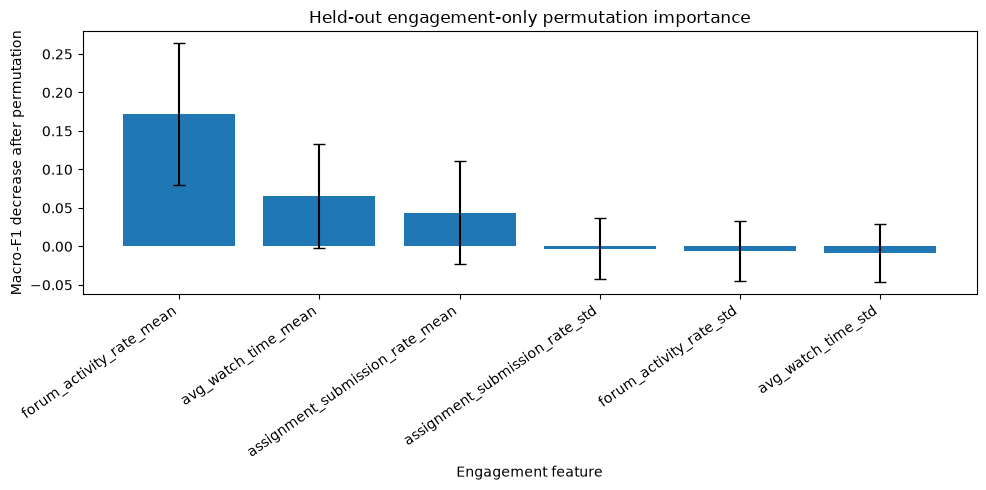

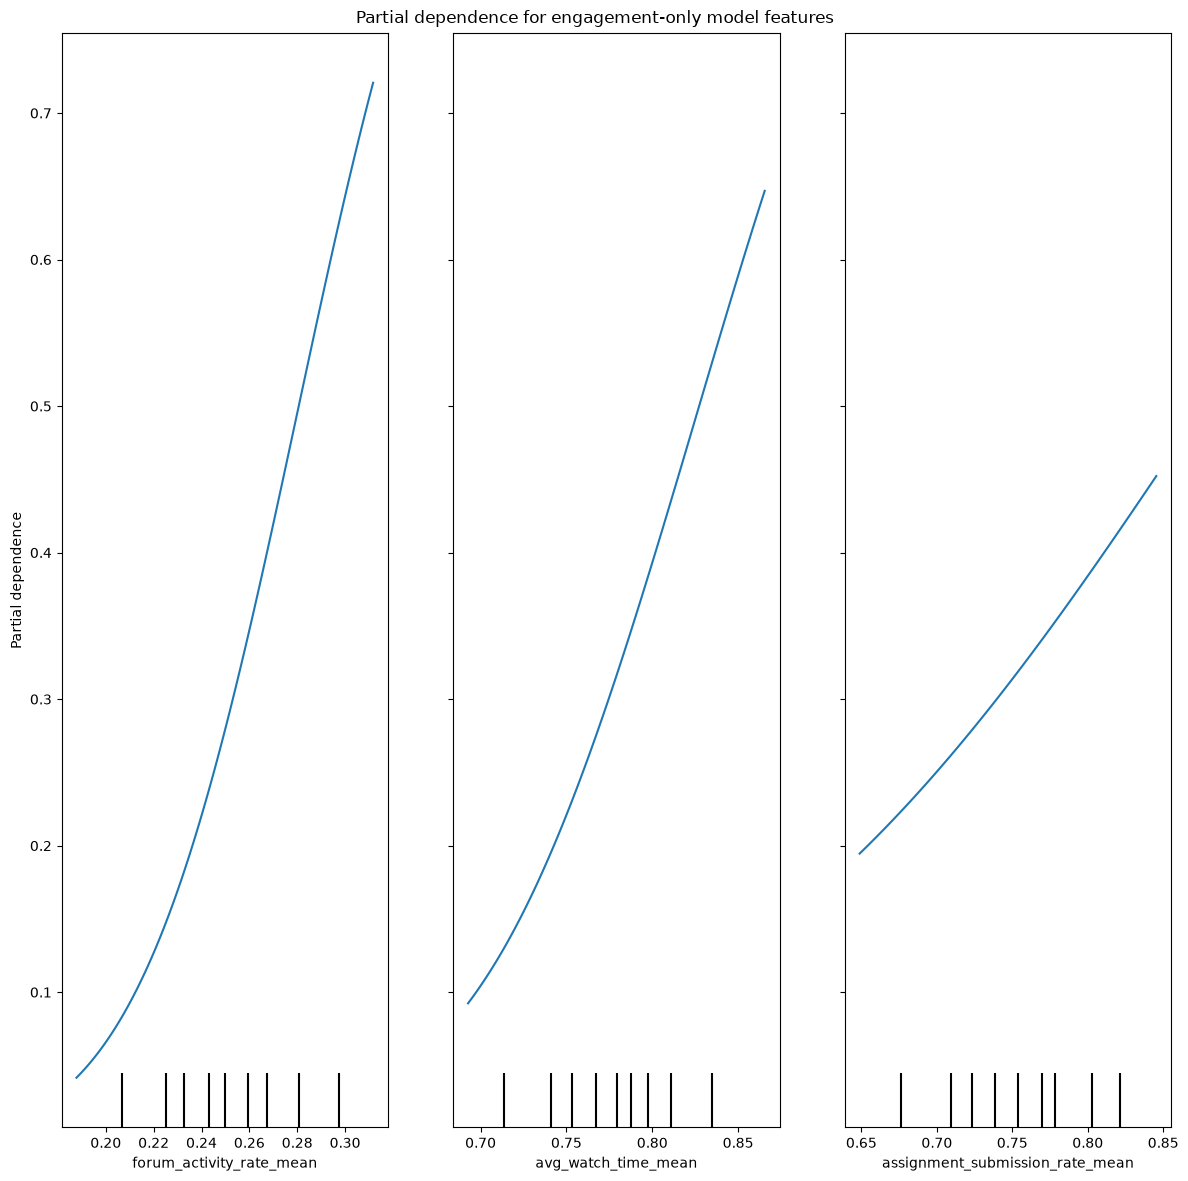

In [8]:
# Held-out permutation importance and partial dependence use the reported engagement-only model and X_engagement.
importance_rows = []
for repeat in range(repeats):
    splitter = StratifiedGroupKFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE + repeat)
    for train_idx, test_idx in splitter.split(X_engagement, y, groups):
        fitted = clone(models["Engagement-only Logistic"]).fit(X_engagement.iloc[train_idx], y.iloc[train_idx])
        baseline_predictions = fitted.predict(X_engagement.iloc[test_idx])
        baseline_score = f1_score(y.iloc[test_idx], baseline_predictions, average="macro")
        rng = np.random.default_rng(RANDOM_STATE + repeat)
        for feature in selected_engagement_features:
            scores = []
            for _ in range(5):
                permuted = X_engagement.iloc[test_idx].copy()
                permuted[feature] = rng.permutation(permuted[feature].to_numpy())
                scores.append(baseline_score - f1_score(y.iloc[test_idx], fitted.predict(permuted), average="macro"))
            importance_rows.append({"feature": feature, "importance": float(np.mean(scores))})
importance_table = pd.DataFrame(importance_rows).groupby("feature")["importance"].agg(["mean", "std"]).sort_values("mean", ascending=False)
driver_table = importance_table[importance_table["mean"] > importance_table["std"]]
zero_like_features = importance_table.index.difference(driver_table.index).tolist()
print("Held-out permutation importance mean +/- std for Engagement-only Logistic on X_engagement:\n", importance_table)
print("Drivers with mean importance > 1 std:\n", driver_table)
print("Not distinguishable from zero:", zero_like_features)
plt.figure(figsize=(10, 5))
plt.bar(importance_table.index, importance_table["mean"], yerr=importance_table["std"], capsize=4)
plt.title("Held-out engagement-only permutation importance")
plt.xlabel("Engagement feature")
plt.ylabel("Macro-F1 decrease after permutation")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plot_features = list(importance_table.head(min(3, len(importance_table))).index)
if plot_features:
    fig, ax = plt.subplots(figsize=(12, 4 * len(plot_features)))
    fitted_engagement = clone(models["Engagement-only Logistic"]).fit(X_engagement, y)
    PartialDependenceDisplay.from_estimator(fitted_engagement, X_engagement, plot_features, target="High", ax=ax)
    plt.suptitle("Partial dependence for engagement-only model features")
    plt.tight_layout()
print("Product uses: coaching cards can surface actionable engagement patterns; early-warning flags can prompt support; batch allocation support can combine this proxy with context and human review.")


### Interpretation of Held-Out Importance and Partial Dependence

The bar chart reports held-out macro-F1 decrease with error bars; only features whose mean exceeds one standard deviation are treated as distinguishable drivers. The partial-dependence plots use the same Engagement-only Logistic estimator and `X_engagement` feature set as the reported model.


## 9. Sensitivity and Stability

Bootstrap agreement is the primary stability result. Weight perturbations use a Dirichlet distribution centred on the stated weights; the small-sample simulation follows separately.


In [9]:
# A. Stability: 200 Dirichlet weight perturbations and 200 bootstrap resamples.
rng = np.random.default_rng(RANDOM_STATE)
base_components = df.groupby("instructor_id")[["learning_outcomes", "feedback_component", "consistency_component"]].mean()
base_tiers = instructor_scores["tier"].astype(str)
dirichlet_concentration = 20
stability = []
for _ in range(200):
    # Concentration 20 keeps perturbations near the stated 0.60/0.25/0.15 assumptions.
    weights = rng.dirichlet([0.60 * dirichlet_concentration, 0.25 * dirichlet_concentration, 0.15 * dirichlet_concentration])
    perturbed = base_components.to_numpy() @ weights
    perturbed_cuts = np.quantile(perturbed, [1 / 3, 2 / 3])
    tiers = pd.cut(perturbed, bins=[-np.inf, *perturbed_cuts, np.inf], labels=["Low", "Medium", "High"], include_lowest=True).astype(str)
    stability.append(np.mean(tiers.to_numpy() == base_tiers.reindex(base_components.index).to_numpy()) * 100)

bootstrap_agreement = []
for _ in range(200):
    # Bootstrap demonstrates sampling instability while preserving reproducibility.
    sample = df.sample(frac=1, replace=True, random_state=int(rng.integers(0, 1_000_000)))
    boot_scores = sample.groupby("instructor_id")["effectiveness_score"].mean().reindex(instructor_scores.index).fillna(instructor_scores["raw_mean"])
    boot_tiers = pd.cut(boot_scores, bins=[-np.inf, *shrunk_cuts, np.inf], labels=["Low", "Medium", "High"], include_lowest=True).astype(str)
    bootstrap_agreement.append(np.mean(boot_tiers.to_numpy() == base_tiers.to_numpy()) * 100)

boundary_distance = np.minimum(abs(instructor_scores["shrunk_score"] - shrunk_cuts[0]), abs(instructor_scores["shrunk_score"] - shrunk_cuts[1]))
borderline = boundary_distance.sort_values().head(10).index.tolist()
stability_pct = float(np.mean(stability))
bootstrap_pct = float(np.mean(bootstrap_agreement))
print("Dirichlet concentration:", dirichlet_concentration)
print("Mean tier stability under 200 weight perturbations (%):", round(stability_pct, 2))
print("Mean bootstrap tier agreement (%):", round(bootstrap_pct, 2))
print("Borderline instructors:", borderline)


Dirichlet concentration: 20
Mean tier stability under 200 weight perturbations (%): 97.84
Mean bootstrap tier agreement (%): 87.44
Borderline instructors: ['I_084', 'I_055', 'I_120', 'I_064', 'I_008', 'I_115', 'I_109', 'I_048', 'I_065', 'I_082']


### A. Stability Interpretation

Bootstrap agreement is the primary stability result. The Dirichlet concentration is printed above, and the real dataset has a minimum of 7 batches per instructor; the separate simulation demonstrates smaller samples.


### B. Small-Sample Shrinkage Simulation

The simulation repeats 200 times. Each repetition samples 20 real instructors and 1-3 real batches per instructor, using seeded draws. It compares raw and shrunk scores and tiers with full-data references.


In [10]:
# Repeat the small-sample experiment 200 times using only real batches.
simulation_rng = np.random.default_rng(RANDOM_STATE)
simulation_rows = []
for repetition in range(200):
    sampled_instructors = simulation_rng.choice(instructor_scores.index.to_numpy(), size=min(20, len(instructor_scores)), replace=False)
    for instructor_id in sampled_instructors:
        instructor_batches = df[df["instructor_id"] == instructor_id]
        sample_size = int(simulation_rng.integers(1, 4))
        sampled_batches = instructor_batches.sample(n=sample_size, random_state=int(simulation_rng.integers(0, 1_000_000)))
        simulated_raw = float(sampled_batches["effectiveness_score"].mean())
        simulated_weight = sample_size / (sample_size + prior_strength)
        simulated_shrunk = simulated_weight * simulated_raw + (1 - simulated_weight) * global_mean
        full_score = float(instructor_scores.loc[instructor_id, "raw_mean"])
        raw_tier = str(pd.cut([simulated_raw], bins=[-np.inf, *raw_cuts, np.inf], labels=["Low", "Medium", "High"], include_lowest=True)[0])
        shrunk_tier = str(pd.cut([simulated_shrunk], bins=[-np.inf, *shrunk_cuts, np.inf], labels=["Low", "Medium", "High"], include_lowest=True)[0])
        full_tier = str(instructor_scores.loc[instructor_id, "tier"])
        simulation_rows.append({"raw_error": abs(simulated_raw - full_score), "shrunk_error": abs(simulated_shrunk - full_score), "raw_flip": raw_tier != full_tier, "shrunk_flip": shrunk_tier != full_tier})
simulation_results = pd.DataFrame(simulation_rows)
mean_raw_error = float(simulation_results["raw_error"].mean())
mean_shrunk_error = float(simulation_results["shrunk_error"].mean())
mean_raw_flips = float(simulation_results["raw_flip"].mean())
mean_shrunk_flips = float(simulation_results["shrunk_flip"].mean())
print("Shrinkage simulation repetitions:", 200)
print("Shrinkage simulation instructor-draws:", len(simulation_results))
print("Mean raw absolute error versus full-data score:", round(mean_raw_error, 4))
print("Mean shrunk absolute error versus full-data score:", round(mean_shrunk_error, 4))
print("Mean raw tier flips per repetition:", round(mean_raw_flips, 4))
print("Mean shrunk tier flips per repetition:", round(mean_shrunk_flips, 4))


Shrinkage simulation repetitions: 200
Shrinkage simulation instructor-draws: 4000
Mean raw absolute error versus full-data score: 0.2213
Mean shrunk absolute error versus full-data score: 0.1865
Mean raw tier flips per repetition: 0.3132
Mean shrunk tier flips per repetition: 0.305


### Shrinkage Simulation Interpretation

Across the 200 repetitions, shrinkage reduced mean absolute error from `0.2213` raw to `0.1865` shrunk and reduced mean tier flips from `0.3132` to `0.3050` per repetition. It improved both measures in this simulation but did not remove uncertainty. The observed dataset still has a minimum of 7 batches and 0 raw-to-shrunk tier changes.


### C. Instructor Coaching Card

The card is a coaching aid, not a verdict. Strengths use only positive engagement deltas versus course peers, weaknesses use only negative deltas, and the action is tied to the weakest engagement metric.


In [11]:
# Coaching cards use only positive/negative peer deltas and a metric-specific supportive action.
engagement_columns = ["avg_watch_time", "assignment_submission_rate", "forum_activity_rate"]
course_peer_means = df.groupby("course_id")[engagement_columns].transform("mean")
peer_delta = df[engagement_columns] - course_peer_means
instructor_peer_delta = peer_delta.join(df["instructor_id"]).groupby("instructor_id")[engagement_columns].mean()
high_tier_ids = instructor_scores.index[instructor_scores["tier"].astype(str) == "High"].tolist()
card_ids = list(dict.fromkeys(list(borderline[:2]) + high_tier_ids + list(instructor_scores.sort_values("shrunk_score").index)))[:5]
if not any(str(instructor_scores.loc[instructor_id, "tier"]) == "High" for instructor_id in card_ids):
    card_ids[-1] = high_tier_ids[0]
action_by_metric = {
    "avg_watch_time": "Review pacing and add a short, optional replay prompt.",
    "assignment_submission_rate": "Offer an assignment checkpoint and supportive submission reminder.",
    "forum_activity_rate": "Invite one low-risk discussion prompt and model a response."
}
card_rows = []
for instructor_id in card_ids:
    deltas = instructor_peer_delta.loc[instructor_id]
    positive = deltas[deltas > 0].sort_values(ascending=False).head(2)
    negative = deltas[deltas < 0].sort_values().head(2)
    assert set(positive.index).isdisjoint(set(negative.index))
    assert len(positive) <= 2 and len(negative) <= 2
    strengths = ", ".join(positive.index) if len(positive) else "none clearly above peers"
    weaknesses = ", ".join(negative.index) if len(negative) else "none clearly below peers"
    weakest_metric = str(deltas.idxmin())
    confidence = "review" if bool(instructor_scores.loc[instructor_id, "low_confidence"]) else "high data weight"
    card_rows.append({"instructor_id": instructor_id, "tier": str(instructor_scores.loc[instructor_id, "tier"]), "confidence": confidence, "borderline?": "yes" if instructor_id in borderline else "no", "top strengths vs course peers": strengths, "top weaknesses vs course peers": weaknesses, "supportive action": action_by_metric[weakest_metric]})
coaching_card = pd.DataFrame(card_rows)
assert (coaching_card["tier"] == "High").any()
print("Coaching aid table (not a verdict):\n", coaching_card.to_string(index=False))


Coaching aid table (not a verdict):
 instructor_id   tier       confidence borderline?                   top strengths vs course peers top weaknesses vs course peers                                                  supportive action
        I_084 Medium high data weight         yes      avg_watch_time, assignment_submission_rate       none clearly below peers        Invite one low-risk discussion prompt and model a response.
        I_055   High high data weight         yes             avg_watch_time, forum_activity_rate     assignment_submission_rate Offer an assignment checkpoint and supportive submission reminder.
        I_002   High high data weight          no             avg_watch_time, forum_activity_rate       none clearly below peers Offer an assignment checkpoint and supportive submission reminder.
        I_003   High high data weight          no             forum_activity_rate, avg_watch_time       none clearly below peers Offer an assignment checkpoint and supportive subm

### Coaching Card Interpretation

The table is a coaching aid, not a verdict. It reports at most two positive and two negative peer deltas, never overlaps strengths and weaknesses, marks borderline instructors from the actual list, and chooses support language from the weakest engagement metric.


### D. Plain-language summary for a product team

The dataset contains 2,000 batch rows from 120 instructors, with 40 instructors in each tier by construction. The engagement-only model reached macro-F1 `0.6286 +/- 0.0995`, compared with `0.3719 +/- 0.0853` for the chance baseline. Forum activity was the only distinguishable driver under the mean-greater-than-one-standard-deviation rule. Bootstrap agreement was `87.44%`, so the tiers are fairly stable but not certain. The 200-repeat small-sample simulation reports whether shrinkage improves score error and tier flips, while the real dataset has a minimum of 7 batches and 0 tier changes. This is a coaching aid, not a verdict, and human review is required.


## 10. Mandatory Questions

The answers below use the real printed outputs from this run. They describe associations and uncertainty, not causal proof.


In [12]:
print("Q1 evidence - held-out leading features:", importance_table.head(5).round(4).to_dict("index"))
print("Q2 evidence - feedback nonresponse correlation:", round(float(df[["avg_feedback_score", "feedback_response_rate"]].corr().iloc[0, 1]), 4))
print("Q3 evidence - low-confidence instructors:", int(instructor_scores["low_confidence"].sum()), "of", len(instructor_scores))
print("Q4 available fields:", list(df.columns))
print("Q5 recommendation: not as a sole judge; use for coaching with human review.")


Q1 evidence - held-out leading features: {'forum_activity_rate_mean': {'mean': 0.1721, 'std': 0.0918}, 'avg_watch_time_mean': {'mean': 0.0658, 'std': 0.0673}, 'assignment_submission_rate_mean': {'mean': 0.0437, 'std': 0.0669}, 'assignment_submission_rate_std': {'mean': -0.0028, 'std': 0.0394}, 'forum_activity_rate_std': {'mean': -0.0064, 'std': 0.0389}}
Q2 evidence - feedback nonresponse correlation: 0.1201
Q3 evidence - low-confidence instructors: 16 of 120
Q4 available fields: ['batch_id', 'instructor_id', 'course_id', 'completion_rate', 'avg_score_improvement', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate', 'avg_feedback_score', 'feedback_response_rate', 'positive_dropout', 'z_completion_rate', 'z_dropout_rate', 'z_avg_score_improvement', 'z_avg_quiz_score', 'z_avg_feedback_score', 'z_positive_dropout', 'learning_outcomes', 'feedback_component', 'consistency_component', 'effectiveness_score']
Q5 recommendation: not as a sole 

### Q1. Which features most influenced effectiveness and why?

Only `forum_activity_rate_mean` is distinguishable from zero: its held-out mean importance is `0.1721` versus standard deviation `0.0918`. `avg_watch_time_mean` (`0.0658 +/- 0.0673`), `assignment_submission_rate_mean` (`0.0437 +/- 0.0669`), and all remaining features are not distinguishable from zero under the stated mean-greater-than-one-standard-deviation rule. These are coaching signals, not causal proof.


### Q2. Which variables could be misleading or confounded?

The completion/dropout correlation is `-0.9535`, so those measures are largely redundant. Feedback score and response rate correlate at `0.1201`, but low response can still make feedback unstable; 67 feedback scores equal 5.0. Engagement can be reverse-causal: learners may watch, submit, or post more because outcomes are already going well, not only because engagement causes good outcomes. Course difficulty, learner mix, prior skill, selection effects, and missing context remain confounders.


### Q3. How could the model fail in real-world usage?

The real data have a minimum of 7 batches per instructor, so the few-batch concern does not occur here; the bootstrap simulation demonstrates sampling instability. The final-score ICC is `0.6326`, but the consistency term is constant per instructor and inflates this descriptive statistic. The model can still fail under distribution drift, metric gaming, or changing learner populations and feedback response patterns.


### Q3. How could the model fail in real-world usage?

The real data have a minimum of 7 batches per instructor, so the few-batch concern does not occur here; the 200-repeat simulation demonstrates sampling instability. It reduced mean absolute error from `0.2213` to `0.1865` and mean tier flips from `0.3132` to `0.3050`, so shrinkage improved both measures in this run, but did not eliminate instability. The final-score ICC is `0.6326`, and the consistency term is constant per instructor and inflates this descriptive statistic. The model can still fail under distribution drift, metric gaming, or changing learner populations and feedback response patterns.


### Q5. Should this model be used for instructor performance evaluation?

No, not as a sole judge. Use it for coaching and support with human review, transparency, uncertainty, and an opportunity for instructors to add context. It should not independently determine hiring, pay, promotion, or termination.


## 11. Conclusion, Limitations and Ethics

Bootstrap tier agreement is `87.44%`, and the highest observed model mean is `0.6286 +/- 0.0995`; all production candidates are within one standard deviation, so the differences are not decisive. The score is a proxy, not ground truth. Course adjustment, shrinkage, grouped validation, and stability analysis improve discipline but do not establish causality or fairness. Do not use these tiers alone for hiring, pay, promotion, or termination. Use them for supportive coaching with human review and instructor transparency.


## Results at a glance

Bootstrap tier agreement is `87.44%` across 200 resamples. The highest observed mean is Engagement-only Logistic at macro-F1 `0.6286 +/- 0.0995`, versus stratified-random chance `0.3719 +/- 0.0853` and majority baseline `0.1667 +/- 0.0000`; all four production candidates are within one highest-model standard deviation, so none should be called a definitive winner. The leaky outcome-derived ablation reaches `0.8709 +/- 0.0604`, but that result is circular and is not a deployment result.


## 12. Final Summary Table

The table below is generated from the real run, so the reported values cannot become stale when the CSV changes.


In [13]:
tier_distribution = instructor_scores["tier"].value_counts().reindex(["Low", "Medium", "High"], fill_value=0)
summary_table = pd.DataFrame({
    "Metric": ["Rows", "Instructors", "Low tier", "Medium tier", "High tier", "Highest observed mean model", "Highest macro-F1 mean +/- std", "Chance macro-F1 mean +/- std", "Majority macro-F1 mean +/- std", "Lift versus chance", "Raw-to-shrunk tier changes", "Minimum batches", "Final score ICC", "Dirichlet concentration", "Mean weight stability %", "Mean bootstrap agreement %", "Top drivers"],
    "Value": [len(df), len(instructor_scores), int(tier_distribution["Low"]), int(tier_distribution["Medium"]), int(tier_distribution["High"]), highest_mean_model, f"{highest_mean_f1:.4f} +/- {highest_mean_std:.4f}", f"{chance_f1_mean:.4f} +/- {results_df.loc['Stratified-random chance baseline', 'macro_f1_std']:.4f}", f"{majority_f1_mean:.4f} +/- {results_df.loc['Dummy majority baseline', 'macro_f1_std']:.4f}", round(highest_mean_f1 - chance_f1_mean, 4), tier_changes, int(instructor_scores["n_batches"].min()), round(final_score_icc, 4), dirichlet_concentration, round(stability_pct, 2), round(bootstrap_pct, 2), ", ".join(importance_table.head(3).index)]
})
print(summary_table.to_string(index=False))


                        Metric                                                                          Value
                          Rows                                                                           2000
                   Instructors                                                                            120
                      Low tier                                                                             40
                   Medium tier                                                                             40
                     High tier                                                                             40
   Highest observed mean model                                                       Engagement-only Logistic
 Highest macro-F1 mean +/- std                                                              0.6286 +/- 0.0995
  Chance macro-F1 mean +/- std                                                              0.3719 +/- 0.0853
Majority m